# Classificação com Dados Desbalanceados
*Naive Bayes e Estratégias de Rebalanceamento*


**Autor:** Wellington M. Santos <br>
**LinkedIn:** https://www.linkedin.com/in/wellington-moreira-santos <br>
**Contato:** wsantos08@hotmail.com

---

Neste projeto trabalho com um dataset de concessão de empréstimos de um banco, no qual a variável alvo indica se o cliente honrou (0) ou não honrou (1) o pagamento. A classe de interesse, maus pagadores, representa cerca de 14% dos registros, o que caracteriza um problema de dados desbalanceados. Nessas condições um classificador pode atingir acurácia alta simplesmente prevendo a classe majoritária na maioria dos casos, mascarando um desempenho ruim justamente na classe que o banco mais precisa identificar corretamente.

Utilizo Naive Bayes Gaussiano como classificador base e comparo quatro estratégias para lidar com o desbalanceamento: nenhum tratamento, undersampling com Tomek Links, oversampling com SMOTE e a combinação SMOTETomek. Incluo também um contraponto discutido atualmente na literatura de aprendizado de máquina, que questiona se essas técnicas de resampling realmente superam um simples ajuste do limiar de decisão. A avaliação não se limita à acurácia, priorizo recall e precisão da classe de interesse, validação cruzada estratificada e uma estimativa de custo financeiro esperado por estratégia. As principais ferramentas utilizadas são scikit-learn, imbalanced-learn, pandas, numpy, seaborn e matplotlib.

O notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Exploratória
4. Tratamento e Limpeza dos Dados
5. Preparação para o Modelo
6. Treinamento e Comparação de Estratégias de Balanceamento
7. Avaliação e Comparação Final
8. Conclusão e Considerações Finais
9. Referências


## 1. Imports e Configurações

Utilizo pandas e numpy para manipulação dos dados, seaborn e matplotlib para visualização, scikit-learn para o classificador Naive Bayes, divisão treino/teste, validação cruzada e métricas, e imbalanced-learn para as técnicas de rebalanceamento (Tomek Links, SMOTE, SMOTETomek) e para o Pipeline que evita vazamento de dados durante a validação cruzada.

In [2]:
import session_info
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_curve
)

from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

session_info.show(dependencies=False)

In [3]:
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

RANDOM_STATE = 42

---

## 2. Coleta e Inspeção dos Dados

Carrego o dataset de crédito e faço uma inspeção inicial para entender estrutura, tipos e qualidade dos dados antes de qualquer decisão analítica.

### 2.1 Carregamento e visão geral

In [4]:
try:
    dataset = pd.read_csv('credit_data.csv')
    print('- DADOS CARREGADOS -')
except FileNotFoundError:
    print('Erro ao carregar arquivo, verifique o caminho.')
except Exception as e:
    print(f'Erro desconhecido: {str(e)}')

- DADOS CARREGADOS -


In [5]:
# primeiros registros
dataset.head()

,i#clientid,income,age,loan,c#default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1


In [7]:
# dimensoes
dataset.shape

(2000, 5)

### 2.2 Tipos de dados e valores nulos

In [8]:
# tipos de dados
dataset.dtypes

i#clientid      int64
income        float64
age           float64
loan          float64
c#default       int64
dtype: object

In [9]:
# valores nulos
dataset.isnull().sum()

i#clientid    0
income        0
age           3
loan          0
c#default     0
dtype: int64

### 2.3 Estatísticas descritivas

In [10]:
dataset.describe()

,i#clientid,income,age,loan,c#default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


> `income` tem média e mediana próximas, o que indica certa simetria, com valores entre 20014.48 e 69995.68. `age` tem os 3 valores ausentes já identificados e também valores negativos, um problema que trato na seção 4.4. `loan` também tem média e mediana próximas, mas amplitude maior, de 1.37 a 13766.05.

### 2.4 Distribuição da variável alvo

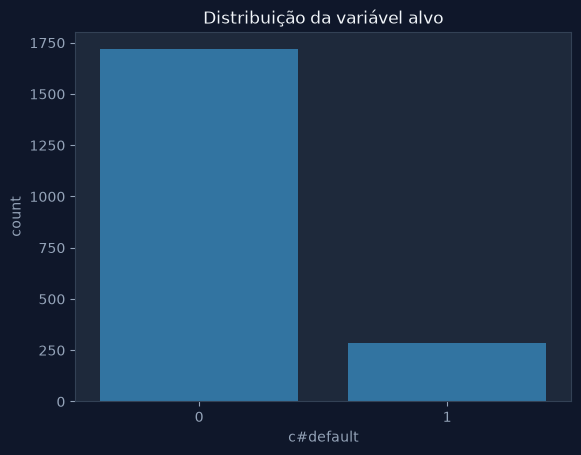

In [11]:
sns.countplot(x=dataset['c#default'])
plt.title('Distribuição da variável alvo')
plt.show()

In [12]:
dataset['c#default'].value_counts(normalize=True)

c#default
0    0.8585
1    0.1415
Name: proportion, dtype: float64

> Há um desbalanceamento acentuado, 85.85% dos clientes desta base histórica são bons pagadores contra 14.15% de maus pagadores, confirmando visualmente o que o gráfico de contagem já mostra.

---

## 3. Análise Exploratória

Investigo como as variáveis disponíveis se relacionam com o alvo antes de treinar qualquer modelo, para entender o que está disponível para o classificador separar as duas classes.

### 3.1 Correlação das variáveis com o alvo

In [13]:
dataset.corr(numeric_only=True)['c#default'].sort_values(ascending=False)

c#default     1.000000
loan          0.377160
income        0.002284
i#clientid   -0.020145
age          -0.429759
Name: c#default, dtype: float64

> `loan` tem a maior correlação positiva com o alvo (0.377) e `age` a maior correlação negativa (-0.430), ainda que `age` nesse ponto do notebook contenha os valores negativos não tratados. `income` tem correlação próxima de zero (0.002), praticamente sem relação linear com o alvo.

### 3.2 Distribuição das variáveis por classe

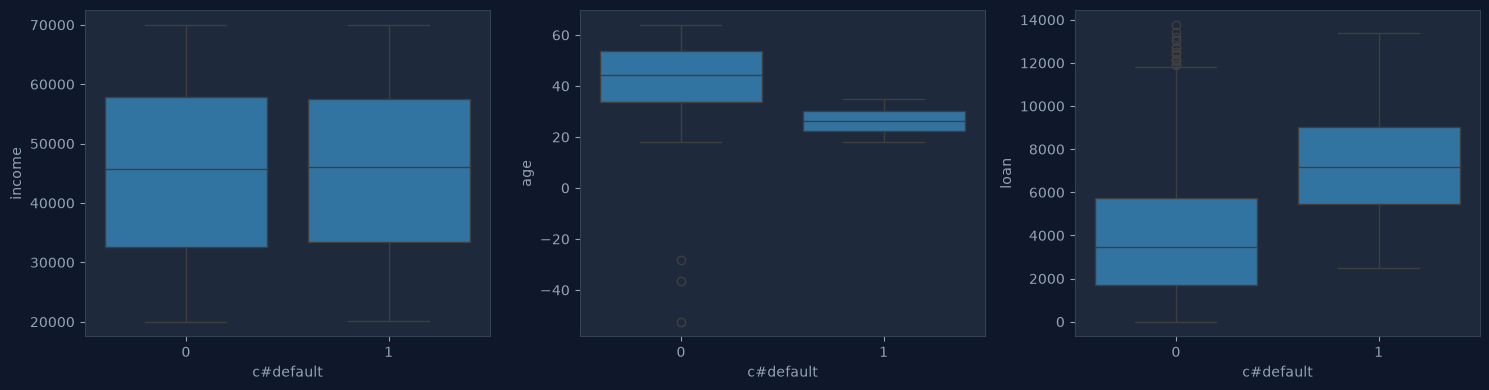

In [14]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
for eixo, coluna in zip(eixos, ['income', 'age', 'loan']):
    sns.boxplot(data=dataset, x='c#default', y=coluna, ax=eixo)
plt.tight_layout()
plt.show()

> Os boxplots confirmam o que a correlação da seção 3.1 já indicava. Em `age`, a classe 1 concentra idades visivelmente mais baixas, com mediana abaixo da classe 0. Em `loan`, a classe 1 concentra valores de empréstimo mais altos, com mediana acima da classe 0. Em `income` as duas classes se sobrepõem quase completamente, coerente com a correlação próxima de zero encontrada na seção anterior. Na prática, é a combinação de idade baixa com empréstimo alto que mais separa um mau pagador de um bom pagador neste dataset, renda isolada não ajuda muito.

### 3.3 Resumo da análise exploratória

A análise exploratória mostra duas variáveis com poder discriminativo real, `age` e `loan`, e uma praticamente sem relação com o alvo, `income`. Isso já sugere que o modelo terá dificuldade em separar bem as classes usando apenas essas três variáveis quando os casos forem menos óbvios, o que reforça a importância de olhar além da acurácia na avaliação. A seção também confirma que `age` ainda carrega valores negativos não tratados neste ponto do notebook, o que trato na próxima seção antes de treinar qualquer modelo.

---

## 4. Tratamento e Limpeza dos Dados

Aplico aqui as verificações de qualidade de dados que uma modelagem real exige antes do treinamento, independentemente do que o material do curso verificou ou não.

### 4.1 Padronização dos nomes de colunas

As colunas originais trazem prefixos de tipo (`i#`, `c#`). Renomeio para nomes diretos, sem alterar os dados.

In [15]:
dataset = dataset.rename(columns={'i#clientid': 'clientid', 'c#default': 'default'})
dataset.columns

Index(['clientid', 'income', 'age', 'loan', 'default'], dtype='str')

### 4.2 Duplicatas

In [16]:
antes = len(dataset)
dataset = dataset.drop_duplicates()
print(f"Registros removidos por duplicidade : {antes - len(dataset)}")
print(f"Registros restantes                 : {len(dataset)}")

Registros removidos por duplicidade : 0
Registros restantes                 : 2000


> Não há duplicatas neste dataset, os 2000 registros permanecem intactos nesta etapa.

### 4.3 Valores nulos

In [17]:
antes = len(dataset)
dataset = dataset.dropna()
print(f"Registros removidos por valores nulos : {antes - len(dataset)}")
print(f"Registros restantes                   : {len(dataset)}")

Registros removidos por valores nulos : 3
Registros restantes                   : 1997


### 4.4 Inconsistências de domínio

Verifico se há mais valores fora do intervalo plausível, como idade negativa, o que é um problema conhecido.

In [18]:
dataset[['income', 'age', 'loan']].agg(['min', 'max'])

,income,age,loan
min,20014.489470,-52.423280,1.377630
max,69995.685578,63.971796,13766.051239


> `age` tem mínimo de -52.42, o que não é um valor plausível. `income` e `loan` têm mínimos e máximos dentro do que se espera para renda e valor de empréstimo.

In [20]:
# mediana de age
dataset['age'].median()

np.float64(41.3171591130085)

In [21]:
# antes
dataset['age'].describe()

count    1997.000000
mean       40.807559
std        13.624469
min       -52.423280
25%        28.990415
50%        41.317159
75%        52.587040
max        63.971796
Name: age, dtype: float64

In [32]:
dataset.loc[ dataset.age <= 0, 'age' ] = dataset.age.median()

In [33]:
#depois
dataset.age.describe()

count    1997.000000
mean       40.928286
std        13.261833
min        18.055189
25%        29.072097
50%        41.317159
75%        52.587040
max        63.971796
Name: age, dtype: float64

> 3 registros tinham idade negativa e foram substituídos pela mediana da distribuição (41.32 anos), em vez de removidos, para não reduzir ainda mais o volume já pequeno da classe minoritária. Opto por correção em vez de remoção.
>
> Como limitação, essa mediana é calculada sobre o dataset completo, antes da divisão treino/teste da seção 5.2, o que é uma forma leve do mesmo problema de vazamento discutido na seção 6. Dado que afeta apenas 3 de 1997 registros, o impacto prático é desprezível, mas registro o ponto por coerência com o rigor metodológico que aplico ao restante do projeto.

### 4.5 Resumo do tratamento

| Etapa | Registros removidos ou alterados | Registros restantes |
|-|-|-|
| Padronização de nomes | 0 | 2000 |
| Duplicatas | 0 | 2000 |
| Valores nulos | 3 removidos | 1997 |
| Idade negativa | 3 corrigidos (mediana) | 1997 |

O dataset final para modelagem tem 1997 registros, uma perda de apenas 0.15% do volume original.

---

## 5. Preparação para o Modelo

### 5.1 Separação de features e alvo

In [34]:
X = dataset[['income', 'age', 'loan']].values
y = dataset['default'].values

In [35]:
X

array([[6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [6.94365796e+04, 5.61526170e+01, 7.37883360e+03]], shape=(1997, 3))

In [36]:
y

array([0, 0, 0, ..., 1, 0, 0], shape=(1997,))

### 5.2 Divisão treino/teste estratificada

Fixo `random_state` na divisão treino/teste. O material do curso não fixa uma semente, o que faz com que cada execução gere uma divisão diferente, e por consequência números de avaliação que não se repetem entre execuções, um problema que encontrei ao conferir os valores do notebook original contra as matrizes de confusão impressas nele. Uso `stratify=y` para preservar a proporção de desbalanceamento em treino e teste.

In [37]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_treinamento.shape, X_teste.shape, y_treinamento.shape, y_teste.shape

((1597, 3), (400, 3), (1597,), (400,))

> Não aplico normalização ou codificação: as três features são numéricas contínuas e como seguirei com Naive Bayes Gaussiano este não é sensível à escala das variáveis, diferente de modelos baseados em distância.

### 5.3 Estratégia de validação cruzada

Além da divisão única treino/teste, uso validação cruzada estratificada para obter uma estimativa mais robusta do recall da classe minoritária, já que um único split de teste com poucas dezenas de casos positivos é sensível ao acaso.

In [38]:
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

---

## 6. Treinamento e Comparação de Estratégias de Balanceamento

Treino o Naive Bayes sob cinco condições diferentes, sempre sobre o mesmo `X_treinamento`/`X_teste` definidos na seção anterior. Diferente do notebook do curso, que aplica SMOTE e Tomek Links sobre o dataset completo antes de dividir em treino e teste, aplico o rebalanceamento apenas em `X_treinamento`/`y_treinamento`. Rebalancear antes do split deixa o conjunto de teste influenciado pela reamostragem, o que é vazamento de dados e infla artificialmente as métricas de avaliação.

In [39]:
resultados = []

def avaliar(nome, y_real, y_previsto):
    resultados.append({
        'estrategia': nome,
        'acuracia': accuracy_score(y_real, y_previsto),
        'precisao_classe1': precision_score(y_real, y_previsto),
        'recall_classe1': recall_score(y_real, y_previsto),
        'f1_classe1': f1_score(y_real, y_previsto),
    })

### 6.1 Baseline: Naive Bayes sem tratamento

In [40]:
modelo_base = GaussianNB()
modelo_base.fit(X_treinamento, y_treinamento)
previsoes_base = modelo_base.predict(X_teste)
avaliar('Baseline (sem tratamento)', y_teste, previsoes_base)

In [41]:
confusion_matrix(y_teste, previsoes_base)

array([[339,   4],
       [ 24,  33]])

> O modelo acerta 339 dos 343 bons pagadores do teste, mas só identifica 33 dos 57 maus pagadores, deixando 24 passar despercebidos.

### 6.2 Undersampling: Tomek Links

Tomek Links remove pares de pontos vizinhos de classes diferentes que estão muito próximos na fronteira de decisão, atuando apenas na classe majoritária. Por remover poucos pontos, tende a alterar pouco a proporção original entre as classes.

In [42]:
tl = TomekLinks(sampling_strategy='majority')
X_tl, y_tl = tl.fit_resample(X_treinamento, y_treinamento)
np.unique(y_tl, return_counts=True)

(array([0, 1]), array([1282,  226]))

In [58]:
np.unique(y_treinamento, return_counts=True)

(array([0, 1]), array([1371,  226]))

In [43]:
modelo_tl = GaussianNB()
modelo_tl.fit(X_tl, y_tl)
previsoes_tl = modelo_tl.predict(X_teste)
avaliar('Tomek Links', y_teste, previsoes_tl)

In [57]:
confusion_matrix(y_teste, previsoes_tl)

array([[338,   5],
       [ 22,  35]])

> O treino original tinha 1371 bons pagadores e 226 maus pagadores (85.8% contra 14.2%). Depois do Tomek Links a proporção passa para 1282 contra 226 (85.0% contra 15.0%), uma mudança de menos de 1 ponto percentual porque a técnica só remove pontos de fronteira da classe majoritária, sem tocar na classe minoritária.

### 6.3 Oversampling: SMOTE

SMOTE gera exemplos sintéticos da classe minoritária por interpolação entre vizinhos próximos, equilibrando as classes no conjunto de treino.

In [44]:
smote = SMOTE(sampling_strategy='minority', random_state=RANDOM_STATE)
X_sm, y_sm = smote.fit_resample(X_treinamento, y_treinamento)
np.unique(y_sm, return_counts=True)

(array([0, 1]), array([1371, 1371]))

In [45]:
modelo_sm = GaussianNB()
modelo_sm.fit(X_sm, y_sm)
previsoes_sm = modelo_sm.predict(X_teste)
avaliar('SMOTE', y_teste, previsoes_sm)

In [59]:
confusion_matrix(y_teste, previsoes_sm)

array([[300,  43],
       [  3,  54]])

> Com as classes de treino equilibradas em 1371 contra 1371, o recall da classe 1 salta acima do baseline e do Tomek Links. A precisão da classe 1 cai, o modelo passa a errar mais bons pagadores classificando como maus, mas para o objetivo do banco de identificar quem não vai pagar, esse é o resultado mais forte até aqui.

### 6.4 Combinada: SMOTETomek

SMOTETomek aplica SMOTE para gerar exemplos sintéticos e em seguida usa Tomek Links para limpar sobreposições entre classes geradas na oversampling.

In [46]:
smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_st, y_st = smote_tomek.fit_resample(X_treinamento, y_treinamento)
np.unique(y_st, return_counts=True)

(array([0, 1]), array([1317, 1317]))

In [47]:
modelo_st = GaussianNB()
modelo_st.fit(X_st, y_st)
previsoes_st = modelo_st.predict(X_teste)
avaliar('SMOTETomek', y_teste, previsoes_st)

In [60]:
confusion_matrix(y_teste, previsoes_st)

array([[300,  43],
       [  3,  54]])

> A limpeza adicional do Tomek Links depois do SMOTE reduz o treino de 1371 para 1317 exemplos por classe, mas as métricas no conjunto de teste são idênticas às do SMOTE puro, isso faz sentido para o Naive Bayes Gaussiano, que resume cada classe pela média e variância de cada variável. Remover algumas dezenas de pontos de fronteira não muda essas estatísticas o suficiente para alterar a fronteira de decisão. Para este modelo, o passo extra do SMOTETomek não trouxe ganho prático sobre o SMOTE puro.

### 6.5 Contraponto: ajuste de threshold sem resampling

Uma discussão recente entre mantenedores da própria biblioteca imbalanced-learn questiona se técnicas como SMOTE e Tomek Links trazem ganho real quando comparadas a simplesmente calibrar o limiar de decisão do modelo treinado sem qualquer rebalanceamento, argumento central para incluir esta comparação no projeto. Uso o modelo baseline da seção 6.1 e busco o limiar de probabilidade que maximiza o F1 da classe 1, em vez do limiar padrão de 0.5.

In [48]:
probs_base = modelo_base.predict_proba(X_teste)[:, 1]
precisao, recall, thresholds = precision_recall_curve(y_teste, probs_base)
f1_por_threshold = 2 * (precisao * recall) / (precisao + recall + 1e-9)
melhor_threshold = thresholds[np.argmax(f1_por_threshold[:-1])]
melhor_threshold

np.float64(0.4267046240152179)

In [49]:
previsoes_threshold = (probs_base >= melhor_threshold).astype(int)
avaliar(f'Threshold ajustado ({melhor_threshold:.2f})', y_teste, previsoes_threshold)

In [61]:
confusion_matrix(y_teste, previsoes_threshold)

array([[337,   6],
       [ 20,  37]])

> Neste dataset, ajustar o threshold é uma melhoria real e praticamente gratuita sobre o baseline, mas não substitui o resampling quando o objetivo do negócio é maximizar a detecção de maus pagadores, apenas quando o objetivo é equilibrar precisão e recall.

---

## 7. Avaliação e Comparação Final

### 7.1 Métricas consolidadas

In [50]:
df_resultados = pd.DataFrame(resultados).set_index('estrategia').round(4)
df_resultados

,acuracia,precisao_classe1,recall_classe1,f1_classe1
estrategia,,,,
Baseline (sem tratamento),0.9300,0.8919,0.5789,0.7021
Tomek Links,0.9325,0.8750,0.6140,0.7216
SMOTE,0.8850,0.5567,0.9474,0.7013
SMOTETomek,0.8850,0.5567,0.9474,0.7013
Threshold ajustado (0.43),0.9350,0.8605,0.6491,0.7400


> Nenhuma estratégia isolada vence em todas as métricas, o que reflete o trade-off real entre precisão e recall. Se o objetivo do banco é minimizar maus pagadores não identificados, SMOTE e SMOTETomek são as escolhas certas, com recall de 94.74% contra 57.89% do baseline. Se o objetivo é um equilíbrio geral entre falsos positivos e falsos negativos, o threshold ajustado tem o melhor F1. A acurácia, sozinha, teria indicado o threshold ajustado como melhor estratégia, o que mostra na prática por que ela é uma métrica inadequada aqui.

### 7.2 Validação cruzada estratificada

Repito a comparação usando validação cruzada, encapsulando o rebalanceamento em um `Pipeline` do imbalanced-learn para garantir que a reamostragem ocorra apenas dentro de cada fold de treino, nunca no fold de validação.

In [51]:
pipelines_cv = {
    'Baseline': ImbPipeline([('modelo', GaussianNB())]),
    'Tomek Links': ImbPipeline([('resample', TomekLinks(sampling_strategy='majority')), ('modelo', GaussianNB())]),
    'SMOTE': ImbPipeline([('resample', SMOTE(random_state=RANDOM_STATE)), ('modelo', GaussianNB())]),
    'SMOTETomek': ImbPipeline([('resample', SMOTETomek(random_state=RANDOM_STATE)), ('modelo', GaussianNB())]),
}

resultados_cv = {
    nome: cross_val_score(pipeline, X_treinamento, y_treinamento, cv=cv_estrategia, scoring='recall')
    for nome, pipeline in pipelines_cv.items()
}

pd.DataFrame({nome: [scores.mean(), scores.std()] for nome, scores in resultados_cv.items()},
             index=['recall_medio', 'recall_desvio_padrao']).T

,recall_medio,recall_desvio_padrao
Baseline,0.588502,0.049696
Tomek Links,0.615169,0.052601
SMOTE,0.924734,0.051884
SMOTETomek,0.915845,0.055250


> A validação cruzada confirma o ranking do split único: baseline 58.85% de recall médio, Tomek Links 61.52%, SMOTE 92.47%, SMOTETomek 91.58%, todos com desvio padrão entre 5 e 5.5 pontos percentuais. Os valores médios ficam próximos dos observados no split de teste isolado, o que indica que os resultados não são efeito do acaso de uma divisão específica. Um detalhe que só aparece aqui, o SMOTETomek tem recall médio levemente menor que o SMOTE puro (91.58% contra 92.47%), diferença pequena e dentro da faixa do desvio padrão, mas consistente com a hipótese de que a limpeza extra do Tomek depois do SMOTE não ajuda, e pode até remover pontos informativos da classe minoritária. A comparação por validação cruzada não inclui a estratégia de threshold ajustado, que depende de uma curva de precisão-recall calculada a posteriori e não se encaixa diretamente no Pipeline usado aqui.

### 7.3 Curvas de Precision-Recall

Uso curva de precisão-recall em vez de curva ROC, mais adequada para avaliar classificadores em datasets desbalanceados porque não é influenciada pelo grande volume de verdadeiros negativos da classe majoritária.

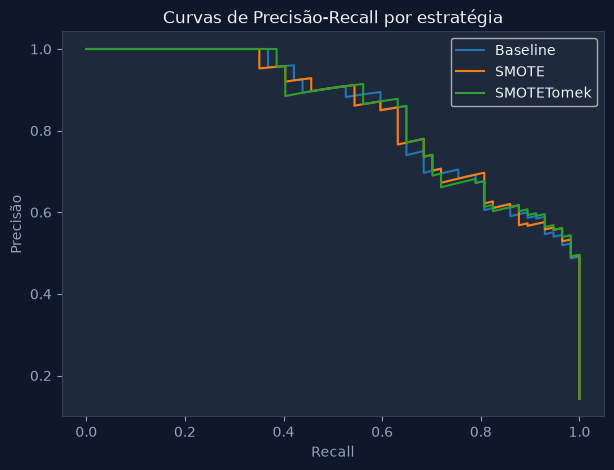

In [52]:
plt.figure(figsize=(7, 5))
for nome, modelo in [('Baseline', modelo_base), ('SMOTE', modelo_sm), ('SMOTETomek', modelo_st)]:
    probs = modelo.predict_proba(X_teste)[:, 1]
    p, r, _ = precision_recall_curve(y_teste, probs)
    plt.plot(r, p, label=nome)
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curvas de Precisão-Recall por estratégia')
plt.legend()
plt.show()

>As curvas de SMOTE e SMOTETomek praticamente se sobrepõem em toda a extensão do gráfico, reforçando o que as seções 6.4 e 7.2 já mostraram, os dois modelos se comportam de forma quase idêntica para este classificador. A curva do baseline se destaca por manter precisão alta apenas na faixa de recall mais baixa, e cair de forma acentuada conforme o recall aumenta, o espelho visual dos números da seção 6.1, o modelo sem tratamento só consegue prever a classe 1 com confiança em poucos casos bem claros. As curvas de SMOTE e SMOTETomek sustentam uma precisão mais alta por uma faixa maior de recall antes de também caírem próximo do limite direito do gráfico.

### 7.4 Impacto financeiro

Retomo a lógica de custo esperado usada no curso, mas calculada a partir das métricas corretas obtidas nas seções anteriores, não dos valores incorretos do notebook original. Considero apenas o custo de não identificar um mau pagador (falso negativo), assumido em R$ 5.000 por caso, para manter a mesma premissa do curso.

In [53]:
custo_por_fn = 5000
mil_maus_pagadores = 1000

def custo_esperado(recall_classe1):
    taxa_erro = 1 - recall_classe1
    return taxa_erro * mil_maus_pagadores * custo_por_fn

df_resultados['custo_esperado_por_1000_maus_pagadores'] = df_resultados['recall_classe1'].apply(custo_esperado)
df_resultados[['recall_classe1', 'custo_esperado_por_1000_maus_pagadores']]

,recall_classe1,custo_esperado_por_1000_maus_pagadores
estrategia,,
Baseline (sem tratamento),0.5789,2105500.0
Tomek Links,0.6140,1930000.0
SMOTE,0.9474,263000.0
SMOTETomek,0.9474,263000.0
Threshold ajustado (0.43),0.6491,1754500.0


>Para cada grupo de 1000 maus pagadores, o custo esperado por deixar de identificá-los cai de R\\$ 2.105.500 no baseline para R\\$ 263.000 com SMOTE ou SMOTETomek, uma economia de aproximadamente R\\$ 1.842.500. 

---

## 8. Conclusão e Considerações Finais

### 8.1 Síntese do Projeto

Treinei um Naive Bayes Gaussiano sobre um dataset de crédito com 14.15% de maus pagadores e comparei cinco formas de lidar com esse desbalanceamento: nenhum tratamento, undersampling com Tomek Links, oversampling com SMOTE, a combinação SMOTETomek e ajuste do limiar de decisão sem qualquer resampling. Os resultados, validados por validação cruzada estratificada, mostram que Tomek Links isoladamente tem efeito quase nulo, SMOTE e SMOTETomek elevam o recall da classe de interesse de 57.89% para 94.74%, e o ajuste de threshold sozinho chega a 64.91% de recall com o melhor F1 entre as cinco estratégias.

| Estratégia | Acurácia | Precisão (classe 1) | Recall (classe 1) | F1 (classe 1) | Custo esperado / 1000 maus pagadores |
|-|-|-|-|-|-|
| Baseline | 0.9300 | 0.8919 | 0.5789 | 0.7021 | R\\$ 2.105.500 |
| Tomek Links | 0.9325 | 0.8750 | 0.6140 | 0.7216 | R\\$ 1.930.000 |
| SMOTE | 0.8850 | 0.5567 | 0.9474 | 0.7013 | R\\$ 263.000 |
| SMOTETomek | 0.8850 | 0.5567 | 0.9474 | 0.7013 | R\\$ 263.000 |
| Threshold ajustado (0.43) | 0.9350 | 0.8605 | 0.6491 | 0.7400 | R\\$ 1.754.500 |

Para o objetivo do banco, identificar maus pagadores, SMOTE é a estratégia recomendada, entre as testadas.

### 8.2 Achados relevantes

Ao conferir o notebook original do curso encontrei dois problemas metodológicos que documento aqui em vez de simplesmente corrigir em silêncio: o `train_test_split` roda sem semente fixa, fazendo os números narrados em texto não corresponderem às matrizes de confusão impressas nas células ao lado; e o SMOTE e o Tomek Links são aplicados sobre o dataset completo antes da divisão treino/teste, o que é vazamento de dados. Neste projeto corrijo os dois pontos.

O ajuste de threshold se mostrou competitivo apenas em parte. Ele supera claramente o baseline sem custo computacional adicional e entrega o melhor F1 do projeto, o que dá razão à discussão que motivou incluí-lo. Mas fica bem atrás de SMOTE e SMOTETomek em recall, 64.91% contra 94.74%. Neste dataset, ajuste de threshold e resampling não são substitutos, são ferramentas para objetivos diferentes, o primeiro equilibra os dois tipos de erro, o segundo prioriza fortemente reduzir os falsos negativos. Também chamo atenção para o fato de o SMOTETomek não ter superado o SMOTE puro em nenhuma métrica neste projeto, o que sugere, para este classificador e este dataset, que o passo extra de limpeza não se paga.

### 8.3 Limitações e Considerações

Este projeto usa apenas três variáveis preditoras (renda, idade e valor do empréstimo) e um dataset de 2000 registros, o que limita a generalização das conclusões. O Naive Bayes Gaussiano assume que as variáveis seguem distribuição normal dentro de cada classe, premissa que não foi testada formalmente aqui. O modelo de custo financeiro considera apenas o custo de aprovar um mau pagador, sem considerar o custo de oportunidade de recusar um bom pagador por engano, o que uma decisão de negócio real também precisaria pesar. Este material tem finalidade educacional, de estudo e composição de portfólio.

---

## 9. Referências

- Estatística para Ciência de Dados e Machine Learning, [IAExpert Academy](https://iaexpert.academy/)
- [imbalanced-learn, User Guide](https://imbalanced-learn.org/stable/introduction.html)
- [scikit-learn, GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)
- [scikit-learn, Precision-Recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html)
- Train in Data, [Should You Use Imbalanced-Learn in 2025?](https://www.blog.trainindata.com/should-you-use-imbalanced-learn-in-2025/), discussão sobre resampling versus ajuste de threshold que motivou a seção 6.5

---

> Material desenvolvido para estudos e composição de portfólio a partir do curso
> [Estatística para Ciência de Dados e Machine Learning](https://iaexpert.academy/), IAExpert Academy, para o repositório
> [data-trivium](https://github.com/esscova/data-trivium);
> com auxílio do Claude Anthropic para revisões e estruturação.